In [1]:
import healpy as hp
import numpy as np
import tensorflow as tf, sys, os
from tensorflow.keras import layers, models, regularizers
import os
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter
import faulthandler, sys, os
faulthandler.enable(all_threads=True)
print("PID:", os.getpid())
print("Python:", sys.version)

tf.keras.backend.clear_session() #clear any previous models

plots_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/"
data_directory = "/mnt/netapp1/Store_CSIC/home/csic/eoy/ioj/SkySimulation/data/simulated_data/"
os.chdir(data_directory)
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1' #disable GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  #suppress TF warnings
print("Current working directory:", os.getcwd())

2025-12-24 04:32:07.652585: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-24 04:32:24.035111: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-24 04:32:30.352640: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64
2025-12-24 04:32:30.352665: I 

PID: 3675591
Python: 3.10.15 | packaged by conda-forge | (main, Oct 16 2024, 01:24:24) [GCC 13.3.0]
Current working directory: /mnt/netapp1/Store_CSIC/home/csic/eoy/ioj/SkySimulation/data/simulated_data


In [2]:
print("TF:", tf.__version__)
print("Python:", sys.version.split()[0])
print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))

TF: 2.10.1
Python: 3.10.15
LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64


In [7]:
from SkyNeuralNets import read_map
#Read the data
path_lcdm = "./simulated_maps/polarization/"
map_temp_data = read_map(path_lcdm + 'cmb_pol_map_U_0.fits')

#Visualize the map
nside = hp.npix2nside(len(map_temp_data))
#nside = 64
print(f"NSIDE: {nside}")

Filename: ./simulated_maps/polarization/cmb_pol_map_U_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
NSIDE: 256


In [8]:
def read_all_maps(path_lcdm, path_feature, n_maps=100, polarization=False):
    """Reads all maps from specified directories and returns them as numpy arrays.
    Args:
        path_lcdm (str): Path to the directory containing LCDM maps.
        path_feature (str): Path to the directory containing feature maps.
        n_maps (int): Number of maps to read from each directory.
    Returns:
        tuple: A tuple containing two numpy arrays - maps and labels.
    """

    maps = []
    labels = []
    
    for i in range(n_maps):
            if polarization:
                lcdm_T = read_map(os.path.join(path_lcdm, f"cmb_pol_map_T_{i}.fits"))
                lcdm_Q = read_map(os.path.join(path_lcdm, f"cmb_pol_map_Q_{i}.fits"))
                lcdm_U = read_map(os.path.join(path_lcdm, f"cmb_pol_map_U_{i}.fits"))
                maps.append(np.stack([lcdm_T, lcdm_Q, lcdm_U], axis=-1))
                labels.append(0)

                feat_T = read_map(os.path.join(path_feature, f"cmb_pol_map_T_feature_{i}.fits"))
                feat_Q = read_map(os.path.join(path_feature, f"cmb_pol_map_Q_feature_{i}.fits"))
                feat_U = read_map(os.path.join(path_feature, f"cmb_pol_map_U_feature_{i}.fits"))
                maps.append(np.stack([feat_T, feat_Q, feat_U], axis=-1))
                labels.append(1)
            else:
                lcdm_T = read_map(os.path.join(path_lcdm, f"cmb_pol_map_T_{i}.fits"))
                maps.append(lcdm_T)
                labels.append(0)

                feat_T = read_map(os.path.join(path_feature, f"cmb_pol_map_feature_T_{i}.fits"))
                maps.append(feat_T)
                labels.append(1)

    maps = np.asarray(maps, dtype=np.float32)
    if not polarization:
        maps = maps[..., None]  # (2N, H, W, 1)

    labels = np.asarray(labels, dtype=np.int32)
    return maps, labels

In [9]:
#from SkyNeuralNets import read_all_maps
path_feature = "./simulated_maps/polarization/"
x_raw, y_raw = read_all_maps(path_lcdm, path_feature, n_maps=224, polarization=True) #0: lcdm, 1:feature

Filename: ./simulated_maps/polarization/cmb_pol_map_T_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/polarization/cmb_pol_map_Q_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/polarization/cmb_pol_map_U_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/polarization/cmb_pol_map_T_feature_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1

In [10]:
x_raw.shape

(448, 786432, 3)

## indices match as follows: 
```[n_map, n_components, T, Q, U], where 0 for T, 1 for Q, 2 for U ```

In [11]:
x_raw = x_raw[:,:,2]

In [12]:
from SkyNeuralNets import map_to_image
imgs = np.array([map_to_image(m) for m in x_raw])
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]  #add channel dimension

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(imgs, y_raw, test_size=0.2, random_state=15)
X_test, X_val, y_test, y_val = train_test_split(imgs, y_raw, test_size=0.2, random_state=15)

In [14]:
np.shape(X_train)

(358, 128, 256, 1)

In [15]:
#Check the class weights to handle imbalance
from sklearn.utils import class_weight
print(f"Training set Class 1 ratio: {y_train.mean():.4f}")
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

Training set Class 1 ratio: 0.5000


In [16]:
from sklearn.decomposition import PCA
# ---- 1. Flatten data ----
orig_shape = X_train.shape[1:]   # e.g. (H, W, 1) or (H, W)
n_features = np.prod(orig_shape)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

# ---- 2. Fit PCA on noise (Class 0 in TRAIN only) ----
n_components = 100  # or 0.999 if you want variance fraction

noise_indices = (y_train == 0)
X_noise_flat  = X_train_flat[noise_indices]

if X_noise_flat.shape[0] == 0:
    raise RuntimeError("No Class 0 maps in y_train, cannot fit PCA")

print("Fitting PCA on noise maps...")
pca = PCA(n_components=n_components, whiten=False)
pca.fit(X_noise_flat)

print(f"Explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

# ---- 3. Subtract noise from all datasets ----
def subtract_noise(X_flat, pca_obj):
    noise_part = pca_obj.inverse_transform(pca_obj.transform(X_flat))
    signal_part = X_flat - noise_part
    return noise_part, signal_part

X_train_noise_flat, X_train_signal_flat = subtract_noise(X_train_flat, pca)
X_val_noise_flat,   X_val_signal_flat   = subtract_noise(X_val_flat,   pca)
X_test_noise_flat,  X_test_signal_flat  = subtract_noise(X_test_flat,  pca)

# Reshape back
X_train_pca = X_train_signal_flat.reshape(X_train.shape).astype(np.float32)
X_val_pca   = X_val_signal_flat.reshape(X_val.shape).astype(np.float32)
X_test_pca  = X_test_signal_flat.reshape(X_test.shape).astype(np.float32)

print("PCA noise subtraction done.")

Fitting PCA on noise maps...
Explained variance: 1.0000
PCA noise subtraction done.


In [17]:
#Check the statistics of the subtracted signal
print("Original Stats:  Mean={:.5f}, Std={:.5f}".format(np.mean(X_train), np.std(X_train)))
print("Signal Stats:    Mean={:.5e}, Std={:.5e}".format(np.mean(X_train_pca), np.std(X_train_pca)))

Original Stats:  Mean=-0.01695, Std=2.96150
Signal Stats:    Mean=-4.95906e-07, Std=1.27515e-03


## Check this part for memory blow up

In [18]:
print(X_train_pca.shape, X_train_pca.dtype)
print(X_val_pca.shape, X_val_pca.dtype)

print("X_train size (GB):", X_train_pca.nbytes / 1024**3)
print("X_val size (GB):", X_val_pca.nbytes / 1024**3)

(358, 128, 256, 1) float32
(90, 128, 256, 1) float32
X_train size (GB): 0.043701171875
X_val size (GB): 0.010986328125


In [19]:
#======== Define Model ========
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),        

    layers.Conv2D(32, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(), layers.ReLU(),

    layers.GlobalAveragePooling2D(),             
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

2025-12-24 04:45:11.139489: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64
2025-12-24 04:45:11.182605: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2025-12-24 04:45:11.231658: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (login211-1): /proc/driver/nvidia/version does not exist
2025-12-24 04:45:12.088777: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
model.summary(110)

cb = [
  tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=300, mode="max", restore_best_weights=True),
  tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=300, mode="max", min_lr=1e-6)
]

Model: "sequential"
______________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                                Param #          
 conv2d (Conv2D)                                 (None, 128, 256, 32)                        288              
                                                                                                              
 batch_normalization (BatchNormalization)        (None, 128, 256, 32)                        128              
                                                                                                              
 re_lu (ReLU)                                    (None, 128, 256, 32)                        0                
                                                                                                              
 max_pooling2d (MaxPooling2D)                    (None, 64, 128, 32)                        

In [21]:
history = model.fit(
    X_train_pca,
    y_train, 
    epochs=1000, 
    batch_size=32, 
    validation_data=(X_val_pca, y_val),
    callbacks=cb,
)

Epoch 1/1000
12/12 [==============================] - 19s 579ms/step - loss: 0.4937 - accuracy: 0.8101 - auc: 0.8998 - val_loss: 0.7015 - val_accuracy: 0.5000 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 2/1000
12/12 [==============================] - 6s 537ms/step - loss: 0.2565 - accuracy: 0.9190 - auc: 0.9907 - val_loss: 0.7017 - val_accuracy: 0.5000 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 3/1000
12/12 [==============================] - 6s 527ms/step - loss: 0.1596 - accuracy: 0.9693 - auc: 0.9975 - val_loss: 0.7022 - val_accuracy: 0.5000 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 4/1000
12/12 [==============================] - 6s 510ms/step - loss: 0.1144 - accuracy: 0.9860 - auc: 0.9995 - val_loss: 0.7023 - val_accuracy: 0.5000 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 5/1000
12/12 [==============================] - 6s 537ms/step - loss: 0.1051 - accuracy: 0.9832 - auc: 0.9979 - val_loss: 0.7015 - val_accuracy: 0.5000 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 6/1000
12/12 [==============

In [22]:
test_loss, test_acc, test_auc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

12/12 [==============================] - 7s 183ms/step - loss: 1.4486 - accuracy: 0.5000 - auc: 0.4486
Test accuracy: 0.5000


In [23]:
model.save("/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/data/CNN_PCA_U_model.h5")

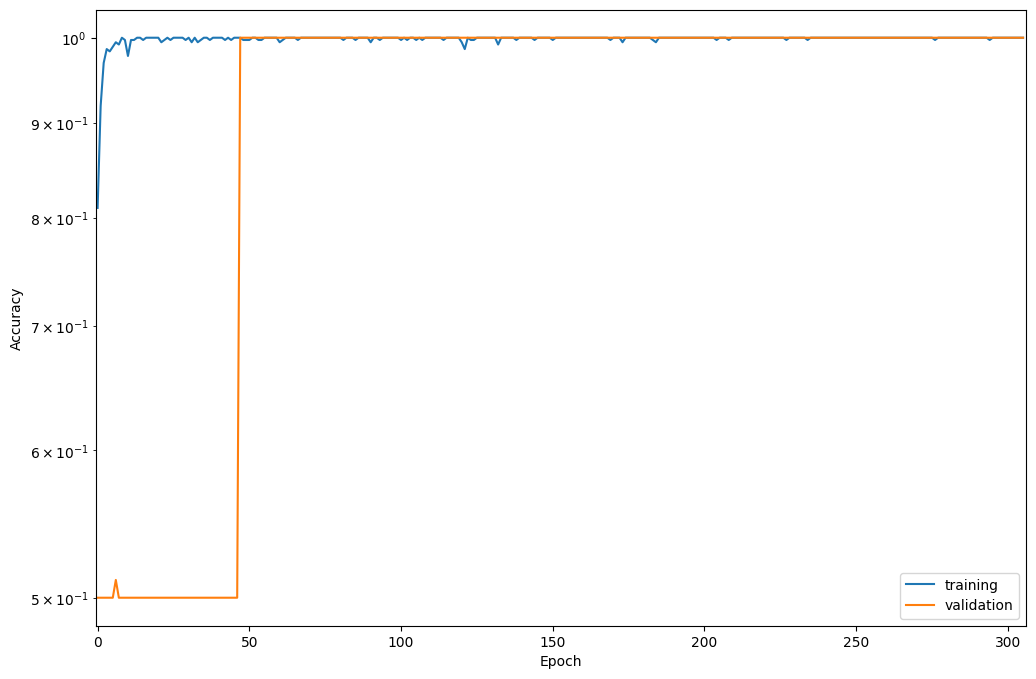

In [24]:
plt.figure(figsize=(12,8))
plt.plot(history.history["accuracy"], label="training")
plt.plot(history.history["val_accuracy"], label="validation")
plt.yscale("log")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xlim(-0.5, len(history.history["accuracy"]))
plt.savefig(f"{plots_directory}Accuracy_CNN_PCA_U.png", dpi=300)
plt.show()

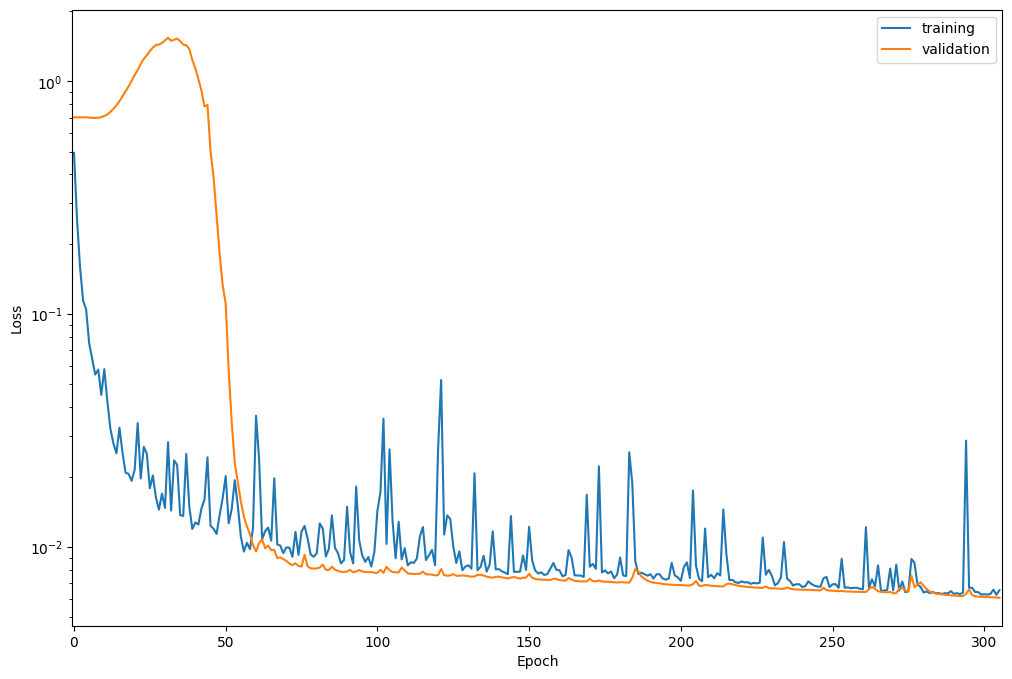

In [25]:
plt.figure(figsize=(12,8))
plt.plot(history.history["loss"], label="training")
plt.plot(history.history["val_loss"], label="validation")
plt.yscale("log")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xlim(-0.5, len(history.history["loss"]))
plt.savefig(f"{plots_directory}Loss_CNN_PCA_U.png", dpi=300)
plt.show()

In [26]:
#Sanity check
print(np.mean(X_train_pca), np.std(X_train_pca))   #mean~0, st.dev~1
print(np.mean(X_test_pca),  np.std(X_test_pca))    #should be close to train

-4.959056e-07 0.0012751467
-4.959056e-07 0.0012751467


In [27]:
#Get model probabilities
probs = model.predict(X_test_pca, batch_size=64).ravel()

6/6 [==============================] - 3s 201ms/step


In [28]:
#Check the class balance, do we have a 50/50 split?
print("class balance test:", (y_test==1).mean())

class balance test: 0.5


In [29]:
#Let's check the ranges of probabilities, why is the CNN classfiying everything as LCDM?
print("min/max/mean probs:", probs.min(), probs.max(), probs.mean())

min/max/mean probs: 0.4773446 0.48325017 0.47880572


In [30]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

#Find optimal threshold from ROC
fpr, tpr, thr = roc_curve(y_test, probs)
t_opt = thr[np.argmax(tpr - fpr)]
print("AUC:", auc(fpr, tpr), "t*:", t_opt)

#Apply the new threshold to get predictions, Youden's index https://en.wikipedia.org/wiki/Youden%27s_J_statistic
pred = (probs >= t_opt).astype(int)

AUC: 1.0 t*: 0.47800526


In [31]:
#Accuracy
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

#Confusion matrix
cm = confusion_matrix(y_test, pred, labels=[0, 1])
print("Confusion matrix:\n", cm)

Accuracy: 1.0
Confusion matrix:
 [[179   0]
 [  0 179]]


In [32]:
#-----------------------------------------------------------------------------------------------------------
#Performance: correct & incorrect  predictions
#-----------------------------------------------------------------------------------------------------------
#True positive: LCDM=0, Feature=1
true_LCDM = []
true_MoG = []
false_LCDM = []
false_MoG = []

for pred, true in zip(pred, y_test):
    if pred==0 and true==0:
        true_LCDM.append(1)
    if pred==1 and true==1:
        true_MoG.append(1)
    if pred==0 and true==1:
        false_LCDM.append(1)
    if pred==1 and true==0:
        false_MoG.append(1)
lenghts=[len(true_LCDM),len(true_MoG),len(false_LCDM),len(false_MoG)]

print('     ','LCDM','FT')
print('True ',len(true_LCDM)/sum(lenghts),len(true_MoG)/sum(lenghts))
print('False',len(false_LCDM)/sum(lenghts),len(false_MoG)/sum(lenghts))
print('--------------')
print("Correct prediction: ",(len(true_LCDM)+len(true_MoG))/sum(lenghts))
print("Wrong prediction  : ",(len(false_LCDM)+len(false_MoG))/sum(lenghts))

      LCDM FT
True  0.5 0.5
False 0.0 0.0
--------------
Correct prediction:  1.0
Wrong prediction  :  0.0


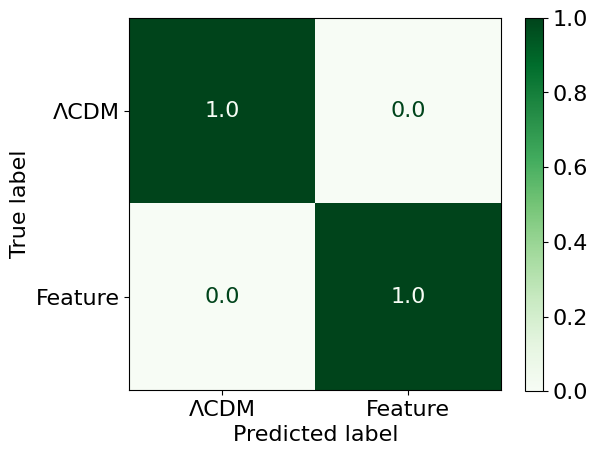

In [36]:
#Plot confusion matrix
fsize = 16
cm_prob = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_prob, display_labels=["ΛCDM", "Feature"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(
    cmap="Greens",
    values_format=".1f",
    ax=ax,
    colorbar=True
)

ax.set_xlabel("Predicted label", fontsize=fsize)
ax.set_ylabel("True label", fontsize=fsize)
ax.tick_params(axis='both', labelsize=fsize) 

for text in ax.texts:
    text.set_fontsize(fsize)

cbar = ax.figure.axes[-1] 
cbar.tick_params(labelsize=fsize)

pos = cbar.get_position()

cbar.set_position([
    pos.x0,         # keep x position
    pos.y0 + 0.01,  # slightly raise it
    pos.width,      
    pos.height * 0.97   # <-- shrink to 70% height
])

plt.savefig(f"{plots_directory}confusion_matrix_CNN_U_PCA.pdf", dpi=300, bbox_inches='tight')
plt.show()

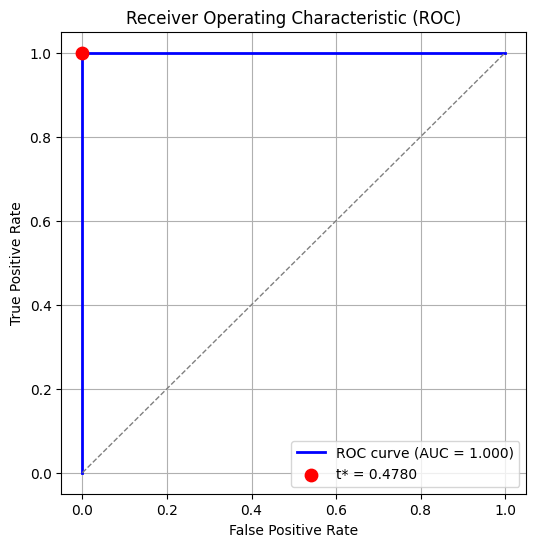

In [35]:
#Plot the ROC curve with Youden index (https://en.wikipedia.org/wiki/Youden%27s_J_statistic#/media/File:ROC_Curve_T1D_Validation,_top5_r2filtered.svg)
from sklearn.metrics import auc
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

t_star_idx = np.argmax(tpr - fpr)
t_star = thr[t_star_idx]

#Mark t* point
plt.scatter(fpr[t_star_idx], tpr[t_star_idx], color="red", s=80, zorder=5,
            label=f"t* = {t_star:.4f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(f"{plots_directory}ROC_CNN_PCA_TE.png", dpi=300)
plt.show()